# Nonlinear MLP Stencil: Learning State-Dependent Finite Differences from Shear-Flow Data

This notebook demonstrates learning a **nonlinear, state-dependent** finite-difference
stencil using shear-flow tracer data.

**Key idea:** Instead of learning 3 fixed (linear) stencil coefficients, we
use an MLP that outputs stencil coefficients as a function of **both** the local
solution state and a **global conditioning** (the entire current field):

$$L[u]_i = \sum_{j \sim i} \bigl(c_j + \delta a_j(\mathbf{u}_{\text{local}}, \mathbf{u}_{\text{global}})\bigr)\, u_j$$

where $\delta a_j$ is an MLP perturbation on top of a base centered-difference
stencil $c_j = [1, -2, 1]/\Delta x^2$.

**Design choices:**
- The stencil is a **nonlinear, globally-conditioned perturbation** of a centered-difference Laplacian.
- Time integration is **explicit Euler**: $u^{n+1} = u^n + \Delta t\, L[u^n]$.
- Training uses **batched rollouts**: all valid starting times are processed in parallel,
  unrolling for a configurable `rollout_len` (e.g., 10 steps) to encourage stability.
- The MLP receives both the 3-point local stencil window and the full current state
  as global context, enabling spatially-varying, state-dependent operators.

> **Note:** A follow-on section at the end of this notebook describes how to extend
> to **implicit Euler** integration with Newton solves. The necessary helper functions
> (tridiagonal solvers, Jacobian assembly) are provided but not used in the main training loop.

## 0. Load Shear-Flow Dataset

In [2]:
# ========================
# MODIFY THESE PARAMETERS
# ========================

# Reynolds number: Valid options are 1e4, 5e4, 1e5, 5e5
Re = 5e5

# Schmidt number: Valid options are 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0
Sc = 2.0e-1

# Initial condition index: 0-39
ic_index = 0

print(f"Target simulation:")
print(f"  Reynolds number: {Re:.0e}")
print(f"  Schmidt number: {Sc:.1f}")
print(f"  Initial condition: {ic_index}")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import os

# Configure matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("\u2713 Libraries imported")

# Construct filename from parameters
filename = f'shearflow_1d_profiles_Re{Re:.0e}_Sc{Sc:.1e}_ic{ic_index}.npz'

# Check if file exists locally
if not Path(filename).exists():
    print(f"\ud83d\udce5 File not found locally: {filename}")
    print(f"   Attempting to download from GitHub repository...")

    # Construct GitHub raw URL
    github_base = "https://raw.githubusercontent.com/natrask/ENM5320-2026/main/NewMaterial/shearflow_project/"
    github_url = github_base + filename

    try:
        print(f"   URL: {github_url}")
        print(f"   Downloading... (this may take a minute for large files)")

        # Download the file
        urllib.request.urlretrieve(github_url, filename)

        file_size_mb = os.path.getsize(filename) / (1024**2)
        print(f"   \u2713 Download complete! ({file_size_mb:.2f} MB)")
        print(f"   Saved to: {Path.cwd() / filename}")

    except urllib.error.HTTPError as e:
        print(f"   \u274c Download failed: {e}")
        print(f"\n   This file may not exist in the repository yet.")
        print(f"   Please run shearflow_preprocessing.ipynb to generate it,")
        print(f"   or choose different parameters (Re, Sc, ic_index).")
        raise FileNotFoundError(f"Could not find or download {filename}")
    except Exception as e:
        print(f"   \u274c Unexpected error: {e}")
        raise
else:
    print(f"\u2713 Found file locally: {filename}")

# Load the data
data = np.load(filename)

print(f"\n\u2713 Data loaded successfully")
print(f"\nAvailable keys in NPZ file:")
for key in data.keys():
    if isinstance(data[key], np.ndarray):
        print(f"  {key:20s}: shape={str(data[key].shape):20s} dtype={data[key].dtype}")
    else:
        print(f"  {key:20s}: {data[key]}")

# Extract basic info
print(f"\nSimulation parameters:")
print(f"  Reynolds number: {data['Re']}")
print(f"  Schmidt number: {data['Sc']}")
print(f"  Initial condition: {data['ic_index']}")

print(f"\nData dimensions:")
print(f"  Time steps: {len(data['time'])}")
print(f"  Spatial points: {len(data['x'])}")
print(f"  Time range: [{data['time'][0]:.2f}, {data['time'][-1]:.2f}]")
print(f"  Spatial range: [{data['x'][0]:.2f}, {data['x'][-1]:.2f}]")

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x79afeee14d60>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 143-144: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^

   ✓ Download complete! (2.42 MB)
   Saved to: /content/shearflow_1d_profiles_Re5e+05_Sc2.0e-01_ic0.npz

✓ Data loaded successfully

Available keys in NPZ file:
  time                : shape=(200,)               dtype=float64
  x                   : shape=(512,)               dtype=float32
  tracer_mean         : shape=(200, 512)           dtype=float32
  tracer_std          : shape=(200, 512)           dtype=float32
  Re                  : shape=()                   dtype=float64
  Sc                  : shape=()                   dtype=float64
  ic_index            : shape=()                   dtype=int32
  velocity_x_mean     : shape=(200, 512)           dtype=float32
  velocity_x_std      : shape=(200, 512)           dtype=float32
  velocity_y_mean     : shape=(200, 512)           dtype=float32
  velocity_y_std      : shape=(200, 512)           dtype=float32
  velocity_mag_mean   : shape=(200, 512)           dtype=float32
  velocity_mag_std    : shape=(200, 512)           dtype=floa

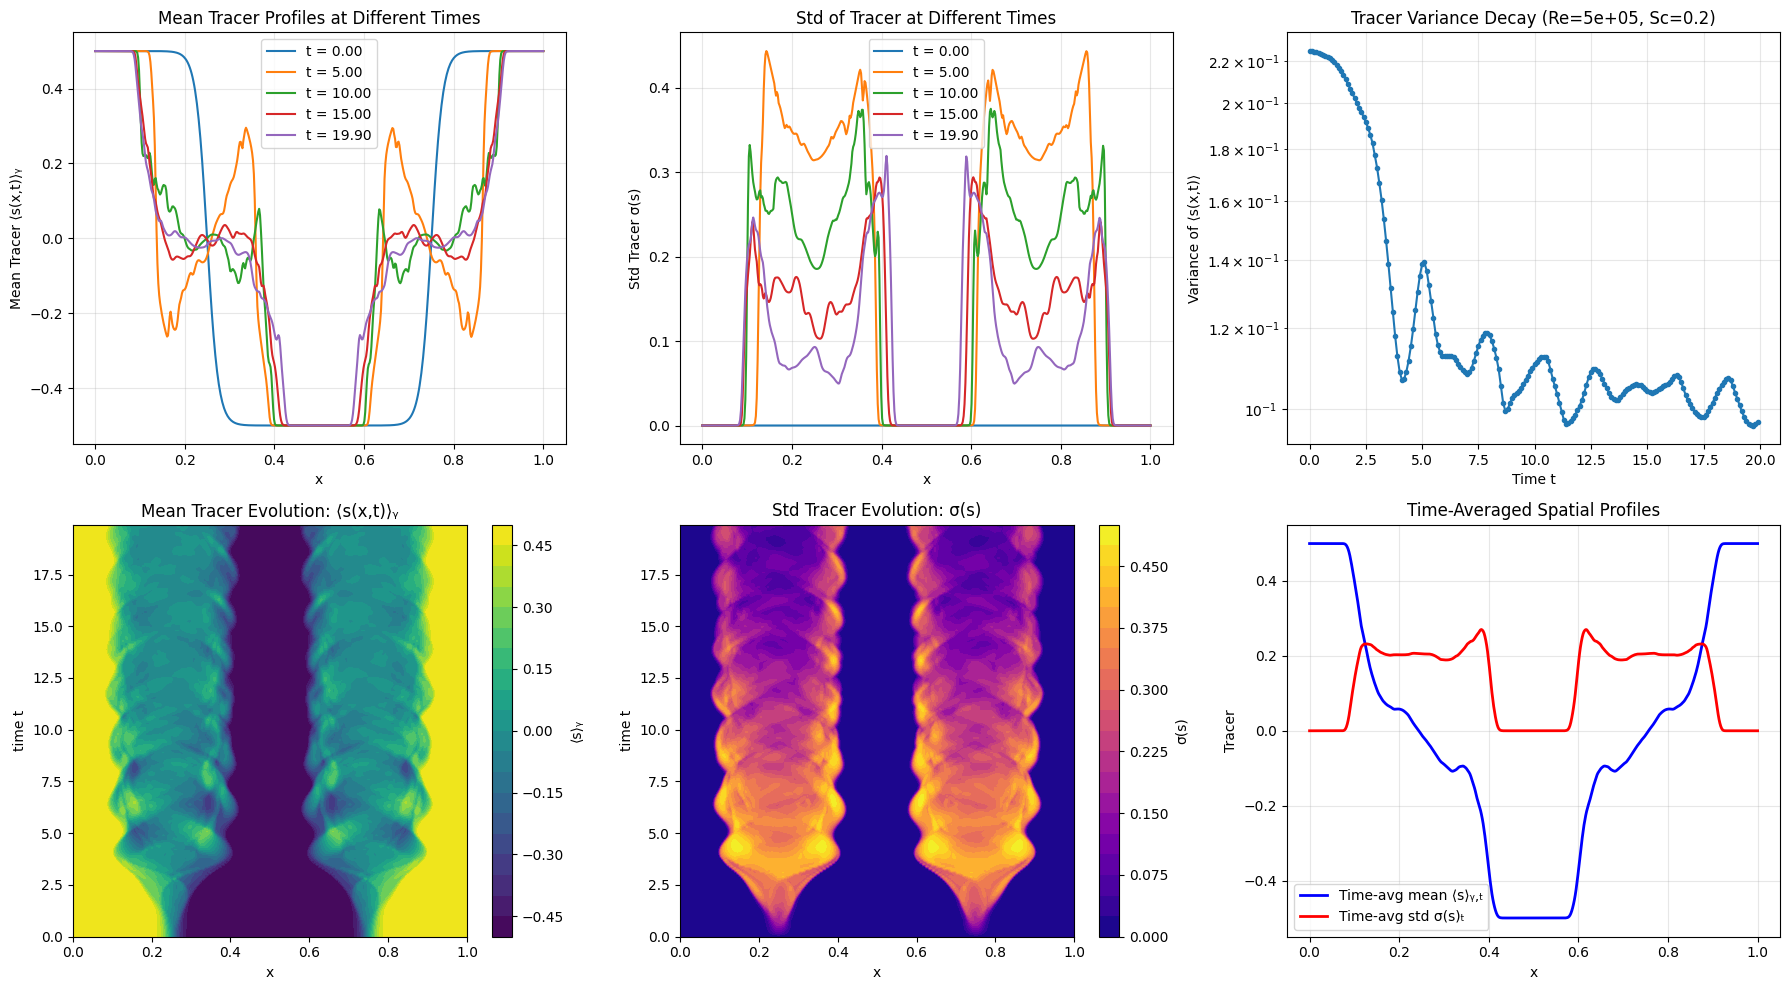


✓ Tracer visualizations complete


In [3]:
# Extract tracer data
time_raw = data['time']
x_raw = data['x']
tracer_mean = data['tracer_mean']
tracer_std = data['tracer_std']

# Create figure with tracer visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Select time indices for 1D plots (start, 1/4, 1/2, 3/4, end)
n_time = len(time_raw)
time_indices = [0, n_time//4, n_time//2, 3*n_time//4, n_time-1]

# Plot 1: Mean tracer at different time snapshots
ax = axes[0, 0]
for t_idx in time_indices:
    ax.plot(x_raw, tracer_mean[t_idx, :], label=f't = {time_raw[t_idx]:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('Mean Tracer \u27e8s(x,t)\u27e9\u1d67')
ax.set_title('Mean Tracer Profiles at Different Times')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Std tracer at different time snapshots
ax = axes[0, 1]
for t_idx in time_indices:
    ax.plot(x_raw, tracer_std[t_idx, :], label=f't = {time_raw[t_idx]:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('Std Tracer \u03c3(s)')
ax.set_title('Std of Tracer at Different Times')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Variance decay over time
ax = axes[0, 2]
variance_over_time = np.var(tracer_mean, axis=1)
ax.semilogy(time_raw, variance_over_time, 'o-', markersize=3)
ax.set_xlabel('Time t')
ax.set_ylabel('Variance of \u27e8s(x,t)\u27e9')
ax.set_title(f'Tracer Variance Decay (Re={Re:.0e}, Sc={Sc:.1f})')
ax.grid(True, alpha=0.3, which='both')

# Plot 4: Heatmap of mean tracer evolution
ax = axes[1, 0]
im = ax.contourf(x_raw, time_raw, tracer_mean, levels=20, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('time t')
ax.set_title('Mean Tracer Evolution: \u27e8s(x,t)\u27e9\u1d67')
plt.colorbar(im, ax=ax, label='\u27e8s\u27e9\u1d67')

# Plot 5: Heatmap of std tracer evolution
ax = axes[1, 1]
im = ax.contourf(x_raw, time_raw, tracer_std, levels=20, cmap='plasma')
ax.set_xlabel('x')
ax.set_ylabel('time t')
ax.set_title('Std Tracer Evolution: \u03c3(s)')
plt.colorbar(im, ax=ax, label='\u03c3(s)')

# Plot 6: Time-averaged spatial profiles
ax = axes[1, 2]
mean_spatial = np.mean(tracer_mean, axis=0)
std_spatial = np.mean(tracer_std, axis=0)
ax.plot(x_raw, mean_spatial, 'b-', linewidth=2, label='Time-avg mean \u27e8s\u27e9\u1d67,\u209c')
ax.plot(x_raw, std_spatial, 'r-', linewidth=2, label='Time-avg std \u03c3(s)\u209c')
ax.set_xlabel('x')
ax.set_ylabel('Tracer')
ax.set_title('Time-Averaged Spatial Profiles')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n\u2713 Tracer visualizations complete")

## 1. Setup: imports and device

In [4]:
import torch
import torch.nn as nn
from torch.func import jacrev, vmap, functional_call

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## 2. Prepare training data

Subsample the loaded shear-flow data in space and skip early transients
(identical to the linear-stencil notebook).

In [5]:
# simplify somewhat
n_skip = 2          # Number of initial timesteps to skip
n_drop = 100        # cut the dataset length
x_subsample = 8     # Spatial subsampling factor

x = data['x'][::x_subsample]
time = data['time'][n_skip:-n_drop]
tracer_mean_sub = data['tracer_mean'][n_skip:-n_drop, ::x_subsample]

N = len(x)
M = len(time) - 1

dx = x[1] - x[0]
dt = time[1] - time[0]

u_true_snapshots = torch.tensor(tracer_mean_sub, dtype=torch.float32).to(device)

print(f"Data preparation complete:")
print(f"  N (spatial points): {N}")
print(f"  M (training timesteps): {M}")
print(f"  dx (spatial step): {dx:.4f}")
print(f"  dt (time step): {dt:.4f}")
print(f"  u_true_snapshots shape: {u_true_snapshots.shape}")

Data preparation complete:
  N (spatial points): 64
  M (training timesteps): 97
  dx (spatial step): 0.0157
  dt (time step): 0.1000
  u_true_snapshots shape: torch.Size([98, 64])


## 3. Define the nonlinear MLP stencil

The MLP takes **two inputs**:
1. A 3-element **local stencil window** $[u_{i-1}, u_i, u_{i+1}]$
2. A **global conditioning vector** (here, the full current state $\mathbf{u}$)

and outputs 3 perturbation weights $[\delta a_{-1}, \delta a_0, \delta a_1]$.

The effective stencil at node $i$ is:
$$a_k^{(i)} = \underbrace{c_k}_{\text{centered diff}} + \underbrace{\delta a_k(\mathbf{u}_{\text{local}}, \mathbf{u}_{\text{global}})}_\text{MLP perturbation}$$


This allows the learned operator to vary spatially based on the global solution structure(e.g., adapting differently in regions of high vs. low concentration).

In [6]:
class StencilMLP(nn.Module):
    """MLP: local window -> stencil perturbation.  Final layer zero-init."""
    def __init__(self, stencil_width=3, hidden=128, global_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(stencil_width+64, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),        nn.Tanh(),
            nn.Linear(hidden, hidden),        nn.Tanh(),
            nn.Linear(hidden, hidden),        nn.Tanh(),
            nn.Linear(hidden, stencil_width) #, nn.Tanh(),
        )
        # Zero-initialise final layer so perturbation is zero at start
        # with torch.no_grad():
            # self.net[-1].weight.zero_()
            # self.net[-1].bias.zero_()

    def forward(self, u_local, u_global):
        if len(u_global.shape) == 1:
            u_global = u_global.unsqueeze(0).repeat(u_local.shape[0],1)
        u_combined = torch.cat([u_local, u_global], dim=1)
        return self.net(u_combined)
        # return self.net(u_local)

## 4. Stencil helpers

We define:
- `extract_stencil_windows` — periodic padding + unfolding to get 3-point windows
- `apply_nonlinear_stencil` — base + MLP perturbation applied to all nodes (single-sample version)
- `implicit_euler_residual` — residual for implicit schemes (used in reach goal section)

In [7]:
def extract_stencil_windows(u, stencil_radius=1):
    """Extract all local stencil windows from u with periodic BCs.
    Returns: (N, 2*stencil_radius+1) tensor of local windows."""
    N = u.shape[0]
    width = 2 * stencil_radius + 1
    u_padded = torch.cat([u[-stencil_radius:], u, u[:stencil_radius]])
    return u_padded.unfold(0, width, 1)


def apply_nonlinear_stencil(u, mlp_params, mlp_buffers, mlp_forward, base_coeffs):
    """Apply L[u]_i = sum_k (base + delta_a_k(window_i)) * window_i[k]."""
    windows = extract_stencil_windows(u)
    delta_a = mlp_forward(mlp_params, mlp_buffers, windows)
    a_eff = base_coeffs.unsqueeze(0) # + delta_a
    return (a_eff * windows).sum(dim=1)


def implicit_euler_residual(u_new, u_old, dt, mlp_params, mlp_buffers,
                            mlp_forward, base_coeffs):
    """F(u_new) = u_new - u_old - dt * L[u_new]."""
    Lu = apply_nonlinear_stencil(u_new, mlp_params, mlp_buffers,
                                 mlp_forward, base_coeffs)
    return u_new - u_old - dt * Lu

## 5. Tridiagonal solvers (for implicit integration — see Reach Goal)

These solvers are provided for the **implicit Euler** extension described at the end.
They solve periodic tridiagonal systems in $O(N)$ via the Thomas algorithm and
Sherman–Morrison correction. **Not used in the explicit training loop.**

In [8]:
def thomas_solve(lower, main, upper, rhs):
    """Solve a (non-periodic) tridiagonal system Ax = rhs in O(N).
    All ops are out-of-place for autograd safety."""
    N = main.shape[0]
    m_list = [main[0]]
    d_list = [rhs[0]]

    for i in range(1, N):
        w = lower[i] / m_list[i - 1]
        m_list.append(main[i] - w * upper[i - 1])
        d_list.append(rhs[i] - w * d_list[i - 1])

    x_list = [None] * N
    x_list[N - 1] = d_list[N - 1] / m_list[N - 1]
    for i in range(N - 2, -1, -1):
        x_list[i] = (d_list[i] - upper[i] * x_list[i + 1]) / m_list[i]

    return torch.stack(x_list)


def periodic_tridiag_solve(lower_diag, main_diag, upper_diag,
                           corner_top_right, corner_bot_left, rhs):
    """Solve a periodic tridiagonal system in O(N) via Sherman-Morrison."""
    N = main_diag.shape[0]
    gamma = -main_diag[0]

    m_mod = torch.cat([
        (main_diag[0] - gamma).unsqueeze(0),
        main_diag[1:N-1],
        (main_diag[N-1] - corner_top_right * corner_bot_left / gamma).unsqueeze(0),
    ])

    u_vec = torch.cat([
        gamma.unsqueeze(0) if gamma.dim() == 0 else gamma.unsqueeze(0),
        torch.zeros(N - 2, dtype=rhs.dtype, device=rhs.device),
        corner_top_right.unsqueeze(0),
    ])

    v_vec = torch.cat([
        torch.ones(1, dtype=rhs.dtype, device=rhs.device),
        torch.zeros(N - 2, dtype=rhs.dtype, device=rhs.device),
        (corner_bot_left / gamma).unsqueeze(0),
    ])

    y = thomas_solve(lower_diag, m_mod, upper_diag, rhs)
    q = thomas_solve(lower_diag, m_mod, upper_diag, u_vec)

    vTy = v_vec.dot(y)
    vTq = v_vec.dot(q)
    return y - (vTy / (1.0 + vTq)) * q

## 6. Jacobian assembly (for implicit integration — see Reach Goal)

This function assembles the Jacobian of the implicit-Euler residual using
`vmap(jacrev(...))` for $O(N)$ complexity. Each row depends only on nodes
$\{i-1, i, i+1\}$. **Not used in the explicit training loop.**

In [9]:
def assemble_jacobian_diags(u_new, u_old, dt, mlp_params, mlp_buffers,
                            mlp_forward, base_coeffs):
    """Assemble the Jacobian as diagonal vectors via vmap+jacrev.
    Returns (lower, main, upper, corner_top_right, corner_bot_left)."""
    N = u_new.shape[0]
    windows = extract_stencil_windows(u_new)

    def local_res_fn(u_local_3, u_old_i):
        delta_a = mlp_forward(mlp_params, mlp_buffers,
                              u_local_3.unsqueeze(0)).squeeze(0)
        a_eff = base_coeffs + delta_a
        Lu_i = (a_eff * u_local_3).sum()
        return u_local_3[1] - u_old_i - dt * Lu_i

    local_jac_fn = jacrev(local_res_fn, argnums=0)
    all_local_jacs = vmap(local_jac_fn)(windows, u_old)  # (N, 3)

    lower = all_local_jacs[:, 0]
    main  = all_local_jacs[:, 1]
    upper = all_local_jacs[:, 2]

    corner_top_right = lower[0].clone()   # J[0, N-1]
    corner_bot_left  = upper[N-1].clone() # J[N-1, 0]

    lower = lower.clone()
    upper = upper.clone()
    lower[0] = 0.0
    upper[N-1] = 0.0

    return lower, main, upper, corner_top_right, corner_bot_left

## 7. Newton solver (for implicit integration — see Reach Goal)

This Newton solver with Armijo backtracking is provided for the **implicit Euler**
extension. It uses a differentiable correction step at convergence (implicit
function theorem) to enable gradient flow. **Not used in the explicit training loop.**

In [10]:
def newton_solve(u_init, u_old, dt, mlp_params, mlp_buffers, mlp_forward,
                 base_coeffs, tol=1e-10, max_iter=20, verbose=False):
    """Solve F(u) = u - u_old - dt*L[u] = 0 via Newton + Armijo.
    O(N) tridiagonal solve, residual reuse, implicit-function correction."""
    u = u_init.detach().clone()
    F_cached = None

    for k in range(max_iter):
        u_prev = u.clone()

        with torch.no_grad():
            if F_cached is not None:
                F_val = F_cached
                F_cached = None
            else:
                F_val = implicit_euler_residual(u, u_old, dt, mlp_params,
                                               mlp_buffers, mlp_forward, base_coeffs)
            res_norm = F_val.norm().item()
            if verbose:
                print(f"  Newton iter {k}: ||F|| = {res_norm:.3e}")
            if res_norm < tol:
                break

        with torch.enable_grad():
            lo, ma, up, ctr, cbl = assemble_jacobian_diags(
                u, u_old, dt, mlp_params, mlp_buffers, mlp_forward, base_coeffs)

        with torch.no_grad():
            delta_u = periodic_tridiag_solve(
                lo.detach(), ma.detach(), up.detach(),
                ctr.detach(), cbl.detach(), -F_val)

            # Armijo backtracking
            alpha = 1.0
            c1 = 1e-4
            tau = 0.5
            phi_current = 0.5 * F_val.dot(F_val)
            directional_deriv = -F_val.dot(F_val)

            F_trial = None
            for _ in range(20):
                u_trial = u + alpha * delta_u
                F_trial = implicit_euler_residual(
                    u_trial, u_old, dt, mlp_params, mlp_buffers,
                    mlp_forward, base_coeffs)
                phi_trial = 0.5 * F_trial.dot(F_trial)
                if phi_trial <= phi_current + c1 * alpha * directional_deriv:
                    break
                alpha *= tau

            u = u + alpha * delta_u
            F_cached = F_trial

    # --- Differentiable correction (implicit function theorem) ---
    u_det = u.detach() # used to be just u
    F_val = implicit_euler_residual(u_det, u_old, dt, mlp_params, mlp_buffers,
                                    mlp_forward, base_coeffs)
    lo, ma, up, ctr, cbl = assemble_jacobian_diags(
        u_det, u_old, dt, mlp_params, mlp_buffers, mlp_forward, base_coeffs)
    delta_u = periodic_tridiag_solve(lo, ma, up, ctr, cbl, -F_val)
    return u_det + delta_u
    # return u

In [11]:
def exp_step(u_old, dt, mlp_params, mlp_buffers, mlp_forward,
                 base_coeffs, tol=1e-10, max_iter=20, verbose=False):
    """
    Explicit Euler step using nonlinear stencil:
    u^{n+1} = u^n + dt * L[u^n],
    where L uses base_coeffs + MLP(u_stencil).
    """
    # Build local windows around u_old
    windows = extract_stencil_windows(u_old)           # shape (N, 3)

    # MLP perturbation of stencil coefficients
    delta_a = mlp_forward(mlp_params, mlp_buffers, windows, u_old)  # (N, 3)

    # Effective stencil coefficients at each node
    a_eff = base_coeffs.unsqueeze(0) + delta_a        # (N, 3)

    # Apply stencil: L[u]_i = sum_k a_eff[i, k] * window[i, k]
    Lu_old = (a_eff * windows).sum(dim=1)             # (N,)

    # Explicit Euler update
    return u_old + dt * Lu_old

## 8. Instantiate model and base stencil

In [12]:
base_coeffs = torch.tensor([1.0, -2.0, 1.0], device=device) # (dx ** 2)

mlp = StencilMLP(stencil_width=3, hidden=128, global_dim=64).to(device)

# Pure-function forward pass for compatibility with vmap/jacrev
mlp_params = dict(mlp.named_parameters())
mlp_buffers = dict(mlp.named_buffers())

def mlp_forward(params, buffers, x, y):
    return functional_call(mlp, (params, buffers), (x,y))

# Verify: at init the perturbation should be ~zero
test_window = torch.randn(1, 3, device=device)
test_global = torch.randn(64, device=device)
print(f"MLP output at init (should be ~0): {mlp_forward(mlp_params, mlp_buffers, test_window, test_global)}")
print(f"\nBase stencil: {base_coeffs.tolist()}")
print(f"Grid: N={N}, dx={dx:.4f}")
print(f"Time: M={M} steps, dt={dt:.6f}")

MLP output at init (should be ~0): tensor([[ 0.1344,  0.0377, -0.0350]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

Base stencil: [1.0, -2.0, 1.0]
Grid: N=64, dx=0.0157
Time: M=97 steps, dt=0.100000


## 9. (Optional) Verify Newton solver

*This cell is commented out.* For implicit integration, you would verify that
the Newton solver matches a direct linear solve when the MLP perturbation is zero.
See the **Reach Goal** section at the end for more details.

In [13]:
# u0 = u_true_snapshots[0].clone()
# # u1_newton = newton_solve(u0, u0, dt, mlp_params, mlp_buffers, mlp_forward,
#                         #  base_coeffs, tol=1e-10, max_iter=10, verbose=True)
# u1_newton = newton_solve_diff(u0, u0, dt, mlp_params, mlp_buffers, mlp_forward,
#                          base_coeffs, tol=1e-10, max_iter=10)


# # Reference: dense linear solve with base stencil
# D_lin = torch.zeros(N, N, device=device)
# for i in range(N):
#     D_lin[i, (i-1) % N] = base_coeffs[0]
#     D_lin[i, i]          = base_coeffs[1]
#     D_lin[i, (i+1) % N] = base_coeffs[2]
# A_lin = torch.eye(N, device=device) - dt * D_lin
# u1_linear = torch.linalg.solve(A_lin, u0)

# print(f"\n||Newton - LinearSolve|| = {(u1_newton - u1_linear).norm():.3e}  (should be ~0)")

## 10. Training loop (Explicit Euler, batched rollouts)

We train the nonlinear MLP stencil to reproduce the shear-flow tracer data
using **explicit Euler** time-stepping. Key features:

- **Batched rollouts:** All valid starting times are processed in parallel.
- **Configurable rollout length:** `rollout_len` controls how many steps to unroll
  before computing loss (longer = more stability pressure, but harder gradients).
- **Cosine annealing LR:** Learning rate decays smoothly over training.
- **Global conditioning:** At each step, the MLP sees both local windows and the
  current predicted field as context.

In [14]:
def extract_stencil_windows_batched(u_batch, stencil_radius=1):
    # u_batch: (B, N)
    B, N = u_batch.shape
    width = 2 * stencil_radius + 1

    # periodic pad along spatial dimension
    u_padded = torch.cat(
        [u_batch[:, -stencil_radius:], u_batch, u_batch[:, :stencil_radius]],
        dim=1
    )  # (B, N + 2r)

    # unfold over spatial dim -> (B, N, width)
    windows = u_padded.unfold(1, width, 1)
    return windows


def apply_nonlinear_stencil_batched(u_batch, mlp_params, mlp_buffers, mlp_forward,
                                    base_coeffs):
    """
    u_batch: (B, N)
    Global features are taken to be the full current state u_batch itself.
    Your StencilMLP must be consistent with this choice of dimension.
    """
    B, N = u_batch.shape
    windows = extract_stencil_windows_batched(u_batch)   # (B, N, 3)
    windows_flat = windows.reshape(B * N, 3)             # (B*N, 3)

    # Global features = current predicted u (shape (B, N))
    # Expand to each spatial location, then flatten:
    # (B, N) -> (B, N, N) -> (B*N, N)
    global_batch = u_batch
    global_expanded = global_batch[:, None, :].expand(B, N, -1)
    global_flat = global_expanded.reshape(B * N, -1)

    # MLP call on (local, global)
    delta_a_flat = mlp_forward(mlp_params, mlp_buffers,
                               windows_flat, global_flat)  # (B*N, 3)
    delta_a = delta_a_flat.view(B, N, 3)                   # (B, N, 3)

    a_eff = base_coeffs.view(1, 1, 3) + delta_a            # (B, N, 3)
    Lu = (a_eff * windows).sum(dim=2)                      # (B, N)
    return Lu


def exp_step_batched(u_old_batch, dt, mlp_params, mlp_buffers,
                     mlp_forward, base_coeffs):
    """
    u_old_batch: (B, N) = all current states in the rollout batch.
    Global features are computed inside as u_old_batch.
    """
    Lu = apply_nonlinear_stencil_batched(
        u_old_batch, mlp_params, mlp_buffers, mlp_forward, base_coeffs
    )  # (B, N)
    return u_old_batch + dt * Lu

In [15]:
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
num_epochs = 50_000
grad_clip_norm = 1.0
rollout_len = 10

# Cosine annealing scheduler: LR decays from 1e-3 -> 0 over num_epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=0.0
)

print(f"{'Epoch':<8} {'Loss':<15} {'GradNorm':<12}")
print("-" * 40)
loss_history = []

M = u_true_snapshots.shape[0] - 1
B = M - rollout_len + 1
if B <= 0:
    raise ValueError("rollout_len is too large for the available time steps")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    mlp_params = dict(mlp.named_parameters())
    mlp_buffers = dict(mlp.named_buffers())

    # initial states over batched rollouts (parallel)
    u_pred = u_true_snapshots[:B].clone()

    total_loss = torch.tensor(0.0, device=device)

    for k in range(rollout_len):
        # explicit step using current predicted u as global features
        u_pred = exp_step_batched(
            u_pred, dt, mlp_params, mlp_buffers, mlp_forward, base_coeffs
        )  # now corresponds to times t = k+1,...,k+1+B-1

        # targets at time t+k+1 for each rollout
        u_target = u_true_snapshots[k + 1 : k + 1 + B]

        step_loss = torch.mean((u_pred - u_target) ** 2)
        total_loss = total_loss + step_loss

    loss = total_loss / rollout_len
    loss.backward()

    gn = torch.nn.utils.clip_grad_norm_(mlp.parameters(), grad_clip_norm).item()
    optimizer.step()
    scheduler.step()  # update learning rate

    loss_history.append(loss.item())
    if epoch % 100 == 0 or epoch == num_epochs - 1:
        lr = scheduler.get_last_lr()[0]
        print(f"{epoch:<8} {loss.item():<15.3e} {gn:<12.3e} lr={lr:.3e} {base_coeffs.detach().cpu().numpy()}")

print("\nTraining complete.")

Epoch    Loss            GradNorm    
----------------------------------------
0        8.962e-03       4.949e-02    lr=1.000e-03 [ 1. -2.  1.]
100      7.267e-03       7.374e-03    lr=1.000e-03 [ 1. -2.  1.]
200      7.083e-03       2.262e-02    lr=1.000e-03 [ 1. -2.  1.]
300      6.708e-03       5.200e-02    lr=9.999e-04 [ 1. -2.  1.]
400      5.361e-03       4.819e-03    lr=9.998e-04 [ 1. -2.  1.]
500      4.918e-03       6.068e-03    lr=9.998e-04 [ 1. -2.  1.]
600      4.654e-03       9.700e-04    lr=9.996e-04 [ 1. -2.  1.]
700      4.372e-03       6.484e-04    lr=9.995e-04 [ 1. -2.  1.]
800      4.212e-03       8.836e-04    lr=9.994e-04 [ 1. -2.  1.]
900      4.038e-03       1.397e-03    lr=9.992e-04 [ 1. -2.  1.]
1000     3.916e-03       2.630e-02    lr=9.990e-04 [ 1. -2.  1.]
1100     3.808e-03       3.772e-02    lr=9.988e-04 [ 1. -2.  1.]
1200     3.448e-03       1.638e-02    lr=9.986e-04 [ 1. -2.  1.]
1300     3.356e-03       3.945e-02    lr=9.983e-04 [ 1. -2.  1.]
1400     3.

## 11. Visualisation

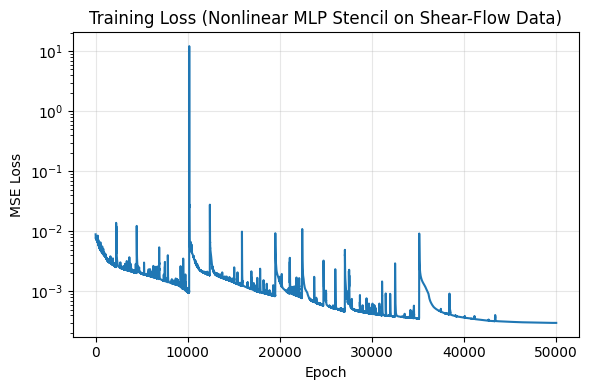

In [16]:
# --- Loss curve ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(loss_history)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss (Nonlinear MLP Stencil on Shear-Flow Data)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

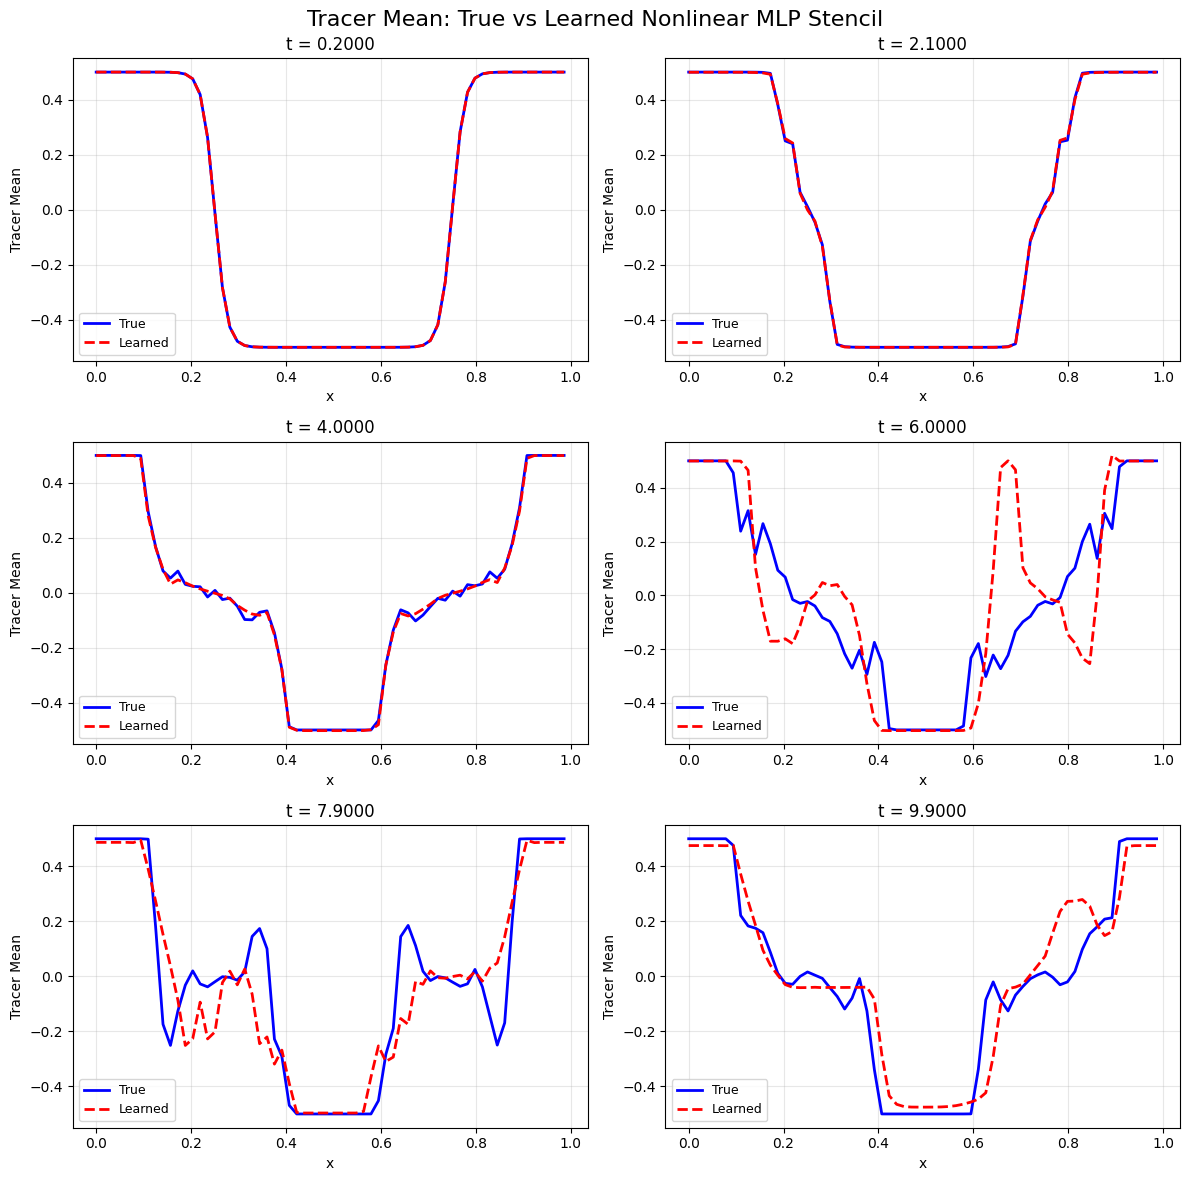

✓ Rollout comparison complete


In [17]:
# --- Roll out learned model and compare to truth ---
mlp.eval()
mlp_params_eval = dict(mlp.named_parameters())
mlp_buffers_eval = dict(mlp.named_buffers())

# Simulate with learned nonlinear stencil
u_learned_history = torch.zeros(M + 1, N, device=device)
u_learned_history[0] = u_true_snapshots[0].clone()

with torch.no_grad():
    for step in range(M):
        # u_learned_history[step + 1] = newton_solve(
        #     u_learned_history[step], u_learned_history[step], dt,
        #     mlp_params_eval, mlp_buffers_eval, mlp_forward,
        #     base_coeffs, tol=1e-10, max_iter=20)
        u_next = exp_step(u_learned_history[step], dt,
                              mlp_params, mlp_buffers, mlp_forward,
                              base_coeffs)
        u_learned_history[step + 1] = u_next

# Convert to numpy for plotting
x_plot = x
t_plot = time
u_true_plot = u_true_snapshots.cpu().numpy()
u_learned_plot = u_learned_history.cpu().numpy()

# Create comparison plot with 3x2 grid (6 snapshots)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Tracer Mean: True vs Learned Nonlinear MLP Stencil', fontsize=16)

num_snapshots = 6
snapshot_indices = [int(i * M / (num_snapshots - 1)) for i in range(num_snapshots)]
snapshot_indices[-1] = M

for idx, snap_idx in enumerate(snapshot_indices):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    ax.plot(x_plot, u_true_plot[snap_idx], 'b-', linewidth=2, label='True')
    ax.plot(x_plot, u_learned_plot[snap_idx], 'r--', linewidth=2, label='Learned')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('Tracer Mean', fontsize=10)
    ax.set_title(f't = {t_plot[snap_idx]:.4f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\u2713 Rollout comparison complete")

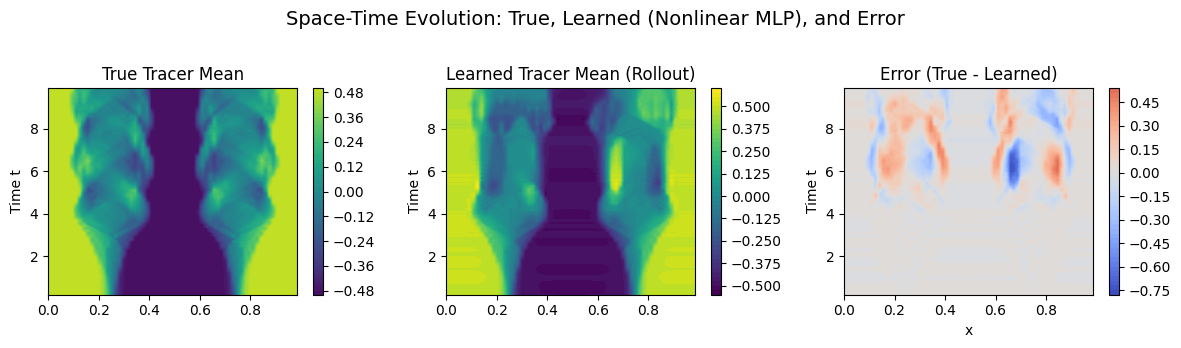

In [18]:
# --- Space-time evolution: True, Learned, and Error ---
u_error_plot = u_true_plot - u_learned_plot

common_vmin_tracer = min(u_true_plot.min(), u_learned_plot.min())
common_vmax_tracer = max(u_true_plot.max(), u_learned_plot.max())

max_abs_error = np.max(np.abs(u_error_plot))
common_vmin_error = -max_abs_error
common_vmax_error = max_abs_error

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)
fig.suptitle('Space-Time Evolution: True, Learned (Nonlinear MLP), and Error', fontsize=14)

ax0 = axes[0]
im0 = ax0.contourf(x_plot, t_plot, u_true_plot, levels=50, cmap='viridis',
                    vmin=common_vmin_tracer, vmax=common_vmax_tracer)
ax0.set_ylabel('Time t')
ax0.set_title('True Tracer Mean')
plt.colorbar(im0, ax=ax0)

ax1 = axes[1]
im1 = ax1.contourf(x_plot, t_plot, u_learned_plot, levels=50, cmap='viridis',
                    vmin=common_vmin_tracer, vmax=common_vmax_tracer)
ax1.set_ylabel('Time t')
ax1.set_title('Learned Tracer Mean (Rollout)')
plt.colorbar(im1, ax=ax1)

ax2 = axes[2]
im2 = ax2.contourf(x_plot, t_plot, u_error_plot, levels=50, cmap='coolwarm',
                    vmin=common_vmin_error, vmax=common_vmax_error)
ax2.set_xlabel('x')
ax2.set_ylabel('Time t')
ax2.set_title('Error (True - Learned)')
plt.colorbar(im2, ax=ax2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 12. Inspect the learned stencil

Evaluate the effective stencil coefficients at each node for the initial condition
to see how the MLP modifies the base Laplacian across the domain.

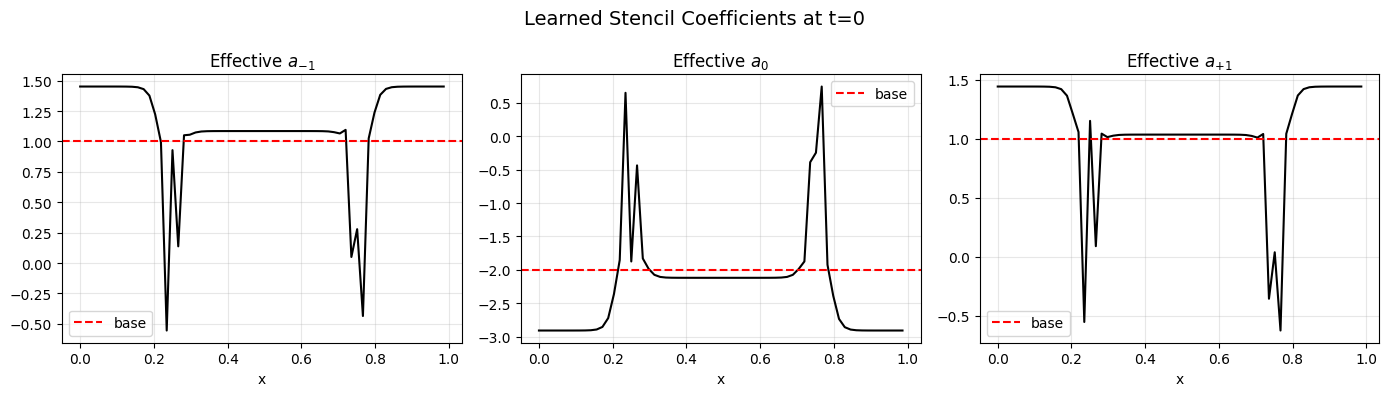

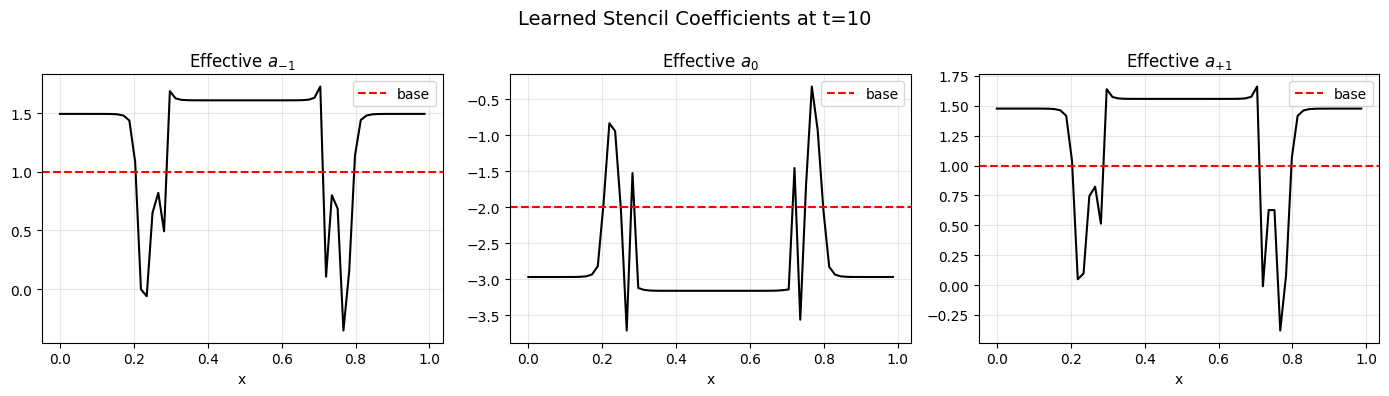

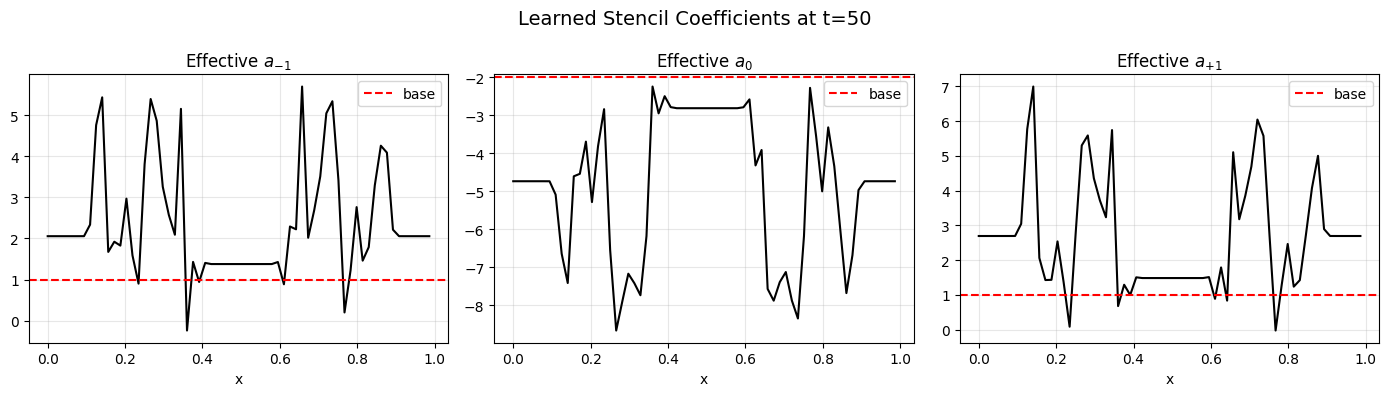

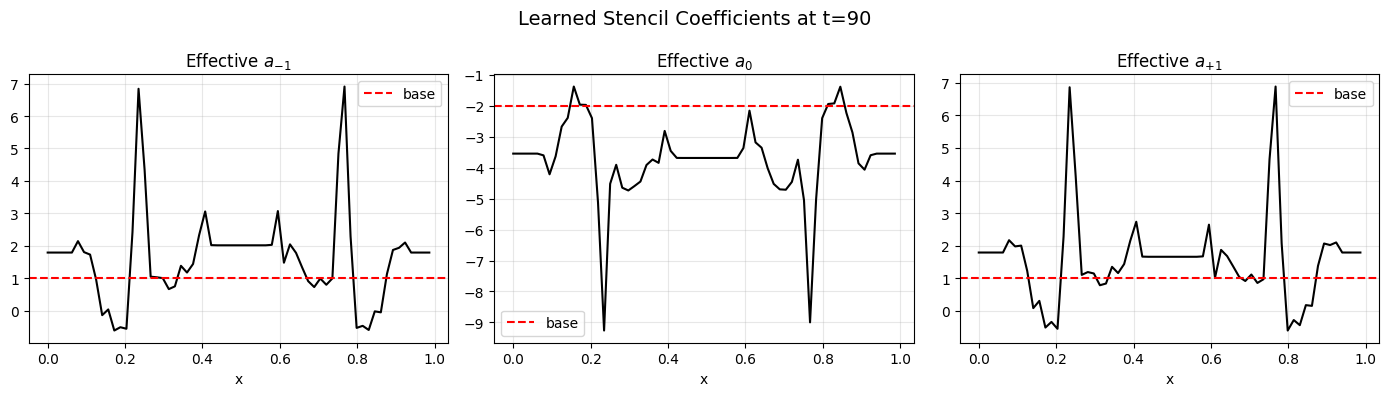

In [19]:
snap_i = 10
for snap_i in [0,10,50,90]:
    with torch.no_grad():
        windows_ic = extract_stencil_windows(u_true_snapshots[snap_i].cpu())
        delta_a_ic = mlp.cpu()(windows_ic, u_true_snapshots[snap_i].cpu())
        a_eff_ic = (base_coeffs.cpu()).unsqueeze(0) + delta_a_ic

    x_np = x
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ['$a_{-1}$', '$a_0$', '$a_{+1}$']
    for k in range(3):
        axes[k].plot(x_np, a_eff_ic[:, k].numpy(), 'k-', lw=1.5)
        axes[k].axhline(base_coeffs[k].item(), color='r', ls='--', label='base')
        axes[k].set_title(f'Effective {labels[k]}')
        axes[k].set_xlabel('x')
        axes[k].legend()
        axes[k].grid(True, alpha=0.3)
    plt.suptitle(f'Learned Stencil Coefficients at t={snap_i}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Move model back to original device
mlp.to(device);

---

## Reach Goal: Implicit Euler Integration

The explicit Euler scheme used above is simple and fully differentiable, but it has
**stability limitations**: the time step $\Delta t$ must satisfy a CFL-like condition
relative to the stiffness of the learned operator. For stiff problems (large diffusion
coefficients, fine grids), this can require very small time steps.

**Implicit Euler** integration offers unconditional stability:
$$u^{n+1} = u^n + \Delta t\, L[u^{n+1}]$$

This requires solving a **nonlinear system** $F(u^{n+1}) = 0$ at each time step, where:
$$F(u) = u - u^n - \Delta t\, L[u]$$

### What's needed for implicit integration

This notebook already provides the building blocks:

1. **`implicit_euler_residual`** (Section 4): Computes $F(u)$ for a given state.

2. **`thomas_solve` and `periodic_tridiag_solve`** (Section 5): $O(N)$ solvers for
   the periodic tridiagonal linear systems that arise when solving for Newton updates.

3. **`assemble_jacobian_diags`** (Section 6): Uses `vmap(jacrev(...))` to efficiently
   compute the Jacobian $\partial F / \partial u$ as tridiagonal + corner entries.

4. **`newton_solve`** (Section 7): Newton's method with Armijo backtracking. The key
   subtlety is enabling gradient flow through the converged solution via the
   **implicit function theorem**:
   - Run Newton iterations with `torch.no_grad()` until convergence
   - Apply one final differentiable correction step: $u \leftarrow u - J^{-1} F(u)$
   - This correction is small (since $F \approx 0$), but it carries gradients w.r.t. MLP parameters

### Challenges with implicit + learned operators

When the operator $L$ depends on learnable parameters, implicit integration introduces:

- **Computational cost:** Each time step requires multiple Newton iterations, each
  involving Jacobian assembly and a tridiagonal solve.

- **Gradient complexity:** The implicit function theorem gives gradients, but they
  require solving an adjoint system or differentiating through the final correction.

- **Warm-starting:** For efficiency, you can cache converged solutions from the
  previous epoch to initialize Newton at the next epoch.

### When to use implicit integration

Consider implicit Euler when:
- Your learned operator is very stiff (large coefficients)
- You need large time steps for efficiency
- Stability is more important than computational cost per step

For many learning problems, explicit Euler with short rollouts (as implemented above)
is sufficient and much simpler to debug.